In [1]:
import math
import time
import jax
import jax.lax as lax
import jax.nn as jnn
import jax.numpy as jnp
import jax.random as jr
import diffrax
import equinox as eqx
import optax
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Set float precision
jax.config.update("jax_enable_x64", True)

In [2]:
def get_ethanol_data(db_path="data.db"):
    """
    Tries to load ethanol data from data.db via ASE.
    Falls back to hardcoded Ethanol coordinates if unavailable.
    """
    try:
        from ase.db import connect
        # Try to read the file
        with connect(db_path) as db:
            row = next(db.select()) # Get strictly the first molecule
            atoms = row.toatoms()
            positions = atoms.get_positions()
            symbols = atoms.get_chemical_symbols()
            print("✅ Successfully loaded molecule from data.db")
            return np.array(positions), symbols
    except Exception as e:
        print(f"⚠️ Could not load from {db_path} (Error: {e}).")
        print("Using hardcoded Ethanol (C2H6O) structure instead.")
        
        # Hardcoded Ethanol approximate structure (Angstroms)
        positions = np.array([
            [ 0.000,  0.000,  0.000], # C1
            [ 1.500,  0.000,  0.000], # C2
            [ 2.000,  1.400,  0.000], # O
            [-0.500,  0.900,  0.000], # H
            [-0.500, -0.500,  0.900], # H
            [-0.500, -0.500, -0.900], # H
            [ 1.800, -0.500,  0.900], # H
            [ 1.800, -0.500, -0.900], # H
            [ 2.900,  1.400,  0.000]  # H
        ])
        symbols = ['C', 'C', 'O', 'H', 'H', 'H', 'H', 'H', 'H']
        return positions, symbols

# Load the data
raw_positions, symbols = get_ethanol_data()

# Pre-processing: Center and Normalize
# We normalize so the neural network handles the scale easier
mean_pos = np.mean(raw_positions, axis=0)
std_scale = np.std(raw_positions) + 1e-6 

normalized_positions = (raw_positions - mean_pos) / std_scale

print(f"Loaded {len(normalized_positions)} atoms.")
print("Symbols:", symbols)

✅ Successfully loaded molecule from data.db
Loaded 9 atoms.
Symbols: ['C', 'C', 'O', 'H', 'H', 'H', 'H', 'H', 'H']


In [3]:
class Func(eqx.Module):
    layers: list[eqx.nn.Linear]

    def __init__(self, *, data_size, width_size, depth, key, **kwargs):
        super().__init__(**kwargs)
        keys = jr.split(key, depth + 1)
        layers = []
        if depth == 0:
            layers.append(ConcatSquash(in_size=data_size, out_size=data_size, key=keys[0]))
        else:
            layers.append(ConcatSquash(in_size=data_size, out_size=width_size, key=keys[0]))
            for i in range(depth - 1):
                layers.append(ConcatSquash(in_size=width_size, out_size=width_size, key=keys[i + 1]))
            layers.append(ConcatSquash(in_size=width_size, out_size=data_size, key=keys[-1]))
        self.layers = layers

    def __call__(self, t, y, args):
        t = jnp.asarray(t)[None]
        for layer in self.layers[:-1]:
            y = layer(t, y)
            y = jnn.tanh(y)
        y = self.layers[-1](t, y)
        return y

class ConcatSquash(eqx.Module):
    lin1: eqx.nn.Linear
    lin2: eqx.nn.Linear
    lin3: eqx.nn.Linear

    def __init__(self, *, in_size, out_size, key, **kwargs):
        super().__init__(**kwargs)
        key1, key2, key3 = jr.split(key, 3)
        self.lin1 = eqx.nn.Linear(in_size, out_size, key=key1)
        self.lin2 = eqx.nn.Linear(1, out_size, key=key2)
        self.lin3 = eqx.nn.Linear(1, out_size, use_bias=False, key=key3)

    def __call__(self, t, y):
        return self.lin1(y) * jnn.sigmoid(self.lin2(t)) + self.lin3(t)

# --- Log Probability Helper wrappers ---

def exact_logp_wrapper(t, y, args):
    y, _ = y
    *args, _, func = args
    fn = lambda y: func(t, y, args)
    f, vjp_fn = jax.vjp(fn, y)
    size = y.size
    eye = jnp.eye(size)
    (dfdy,) = jax.vmap(vjp_fn)(eye)
    logp = jnp.trace(dfdy)
    return f, logp

def normal_log_likelihood(y):
    return -0.5 * (y.size * math.log(2 * math.pi) + jnp.sum(y**2))

class CNF(eqx.Module):
    funcs: list[Func]
    data_size: int
    t0: float
    t1: float
    dt0: float

    def __init__(self, *, data_size, num_blocks, width_size, depth, key, **kwargs):
        super().__init__(**kwargs)
        keys = jr.split(key, num_blocks)
        self.funcs = [
            Func(data_size=data_size, width_size=width_size, depth=depth, key=k)
            for k in keys
        ]
        self.data_size = data_size
        self.t0 = 0.0
        self.t1 = 0.5
        self.dt0 = 0.05

    def train(self, y, *, key):
        term = diffrax.ODETerm(exact_logp_wrapper)
        solver = diffrax.Tsit5()
        eps = jr.normal(key, y.shape)
        delta_log_likelihood = 0.0
        for func in reversed(self.funcs):
            y = (y, delta_log_likelihood)
            sol = diffrax.diffeqsolve(
                term, solver, self.t1, self.t0, -self.dt0, y, (eps, func)
            )
            (y,), (delta_log_likelihood,) = sol.ys
        return delta_log_likelihood + normal_log_likelihood(y)

    def sample_flow(self, *, key):
        # Solves the flow forward to visualize the transformation
        t_so_far = self.t0
        t_end = self.t0 + (self.t1 - self.t0) * len(self.funcs)
        save_times = jnp.linspace(self.t0, t_end, 4) 
        y = jr.normal(key, (self.data_size,))
        out = []
        for i, func in enumerate(self.funcs):
            if i == len(self.funcs) - 1:
                save_ts = save_times[t_so_far <= save_times] - t_so_far
            else:
                save_ts = (
                    save_times[(t_so_far <= save_times) & (save_times < t_so_far + self.t1 - self.t0)]
                    - t_so_far
                )
                t_so_far = t_so_far + self.t1 - self.t0
            term = diffrax.ODETerm(func)
            solver = diffrax.Tsit5()
            saveat = diffrax.SaveAt(ts=save_ts)
            sol = diffrax.diffeqsolve(term, solver, self.t0, self.t1, self.dt0, y, saveat=saveat)
            out.append(sol.ys)
            y = sol.ys[-1]
        out = jnp.concatenate(out)
        return out

In [4]:
class DataLoader(eqx.Module):
    arrays: tuple[jnp.ndarray, ...]
    batch_size: int
    key: jr.PRNGKey

    def __call__(self, step):
        dataset_size = self.arrays[0].shape[0]
        num_batches = dataset_size // self.batch_size
        epoch = step // num_batches
        key = jr.fold_in(self.key, epoch)
        perm = jr.permutation(key, jnp.arange(dataset_size))
        start = (step % num_batches) * self.batch_size
        slice_size = self.batch_size
        batch_indices = lax.dynamic_slice_in_dim(perm, start, slice_size)
        return tuple(array[batch_indices] for array in self.arrays)

# Hyperparameters
SEED = 5678
BATCH_SIZE = 256
LR = 1e-2
STEPS = 50
WIDTH_SIZE = 32
DEPTH = 2
NUM_BLOCKS = 2

key = jr.PRNGKey(SEED)
model_key, loader_key, loss_key, sample_key = jr.split(key, 4)

# Create Dataset: Upsample the 9 atoms to create a dataset of "points"
upsample_factor = 100
dataset = jnp.array(np.tile(normalized_positions, (upsample_factor, 1)))
weights = jnp.ones(dataset.shape[0])

dataloader = DataLoader((dataset, weights), BATCH_SIZE, key=loader_key)

# Initialize Model
model = CNF(
    data_size=3, # 3 Dimensions for X, Y, Z
    num_blocks=NUM_BLOCKS,
    width_size=WIDTH_SIZE,
    depth=DEPTH,
    key=model_key,
)

optim = optax.adamw(LR, weight_decay=1e-5)
opt_state = optim.init(eqx.filter(model, eqx.is_inexact_array))

loss_history = []

Starting training...
Step: 0, Loss: 4.2102
Step: 1, Loss: 4.2218
Step: 2, Loss: 4.0954
Step: 3, Loss: 4.0421
Step: 4, Loss: 4.0217
Step: 5, Loss: 4.0344
Step: 6, Loss: 3.9531
Step: 7, Loss: 3.9252
Step: 8, Loss: 3.9783
Step: 9, Loss: 3.8717
Step: 10, Loss: 3.9195
Step: 11, Loss: 3.8997
Step: 12, Loss: 3.8845
Step: 13, Loss: 3.8376
Step: 14, Loss: 3.8936
Step: 15, Loss: 3.8448
Step: 16, Loss: 3.8537
Step: 17, Loss: 3.8625
Step: 18, Loss: 3.7633
Step: 19, Loss: 3.8424
Step: 20, Loss: 3.8426
Step: 21, Loss: 3.7186
Step: 22, Loss: 3.8241
Step: 23, Loss: 3.7252
Step: 24, Loss: 3.7751
Step: 25, Loss: 3.7124
Step: 26, Loss: 3.7198
Step: 27, Loss: 3.6873
Step: 28, Loss: 3.7115
Step: 29, Loss: 3.6738
Step: 30, Loss: 3.6799
Step: 31, Loss: 3.6296
Step: 32, Loss: 3.5846
Step: 33, Loss: 3.5382
Step: 34, Loss: 3.5300
Step: 35, Loss: 3.4717
Step: 36, Loss: 3.4342
Step: 37, Loss: 3.3566
Step: 38, Loss: 3.3938
Step: 39, Loss: 3.3022
Step: 40, Loss: 3.2796
Step: 41, Loss: 3.2942
Step: 42, Loss: 3.1914


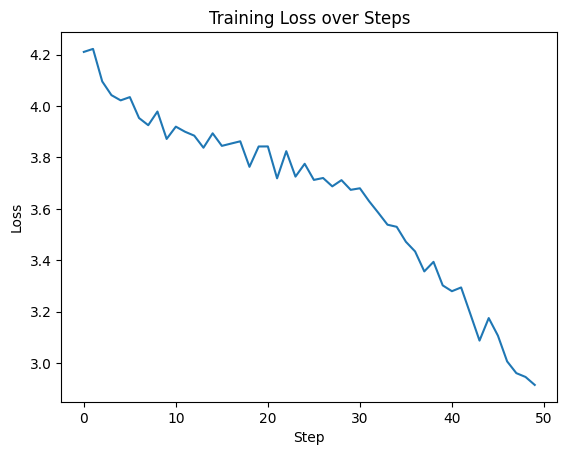

In [5]:
@eqx.filter_value_and_grad
def loss(model, data, weight, loss_key):
    batch_size, _ = data.shape
    noise_key, train_key = jr.split(loss_key, 2)
    train_key = jr.split(train_key, batch_size)
    
    # Add noise to data to make it a continuous distribution (Gaussian Mixture)
    noise_scale = 0.1 
    data = data + jr.normal(noise_key, data.shape) * noise_scale
    
    log_likelihood = jax.vmap(model.train)(data, key=train_key)
    return -jnp.mean(weight * log_likelihood)

@eqx.filter_jit
def make_step(model, opt_state, step, loss_key):
    data, weight = dataloader(step)
    value, grads = loss(model, data, weight, loss_key)
    updates, opt_state = optim.update(grads, opt_state, eqx.filter(model, eqx.is_inexact_array))
    model = eqx.apply_updates(model, updates)
    return value, model, opt_state

print("Starting training...")
for step in range(STEPS):
    loss_key, _ = jr.split(loss_key)
    value, model, opt_state = make_step(model, opt_state, step, loss_key)
    
    if (step % 1) == 0 or step == STEPS - 1:
        print(f"Step: {step}, Loss: {value:.4f}")
    loss_history.append(value)

print("Training complete.")

plt.plot(loss_history)
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training Loss over Steps")
plt.show()

In [22]:
%pip -q install ipympl
%matplotlib widget
import matplotlib as mpl
mpl.rcParams["axes3d.mouserotationstyle"] = "azel"

/home/maxim/jax-neural-odes/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


/tmp/ipykernel_69837/1203098063.py:5: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(figsize=(18, 8 * num_snaps))


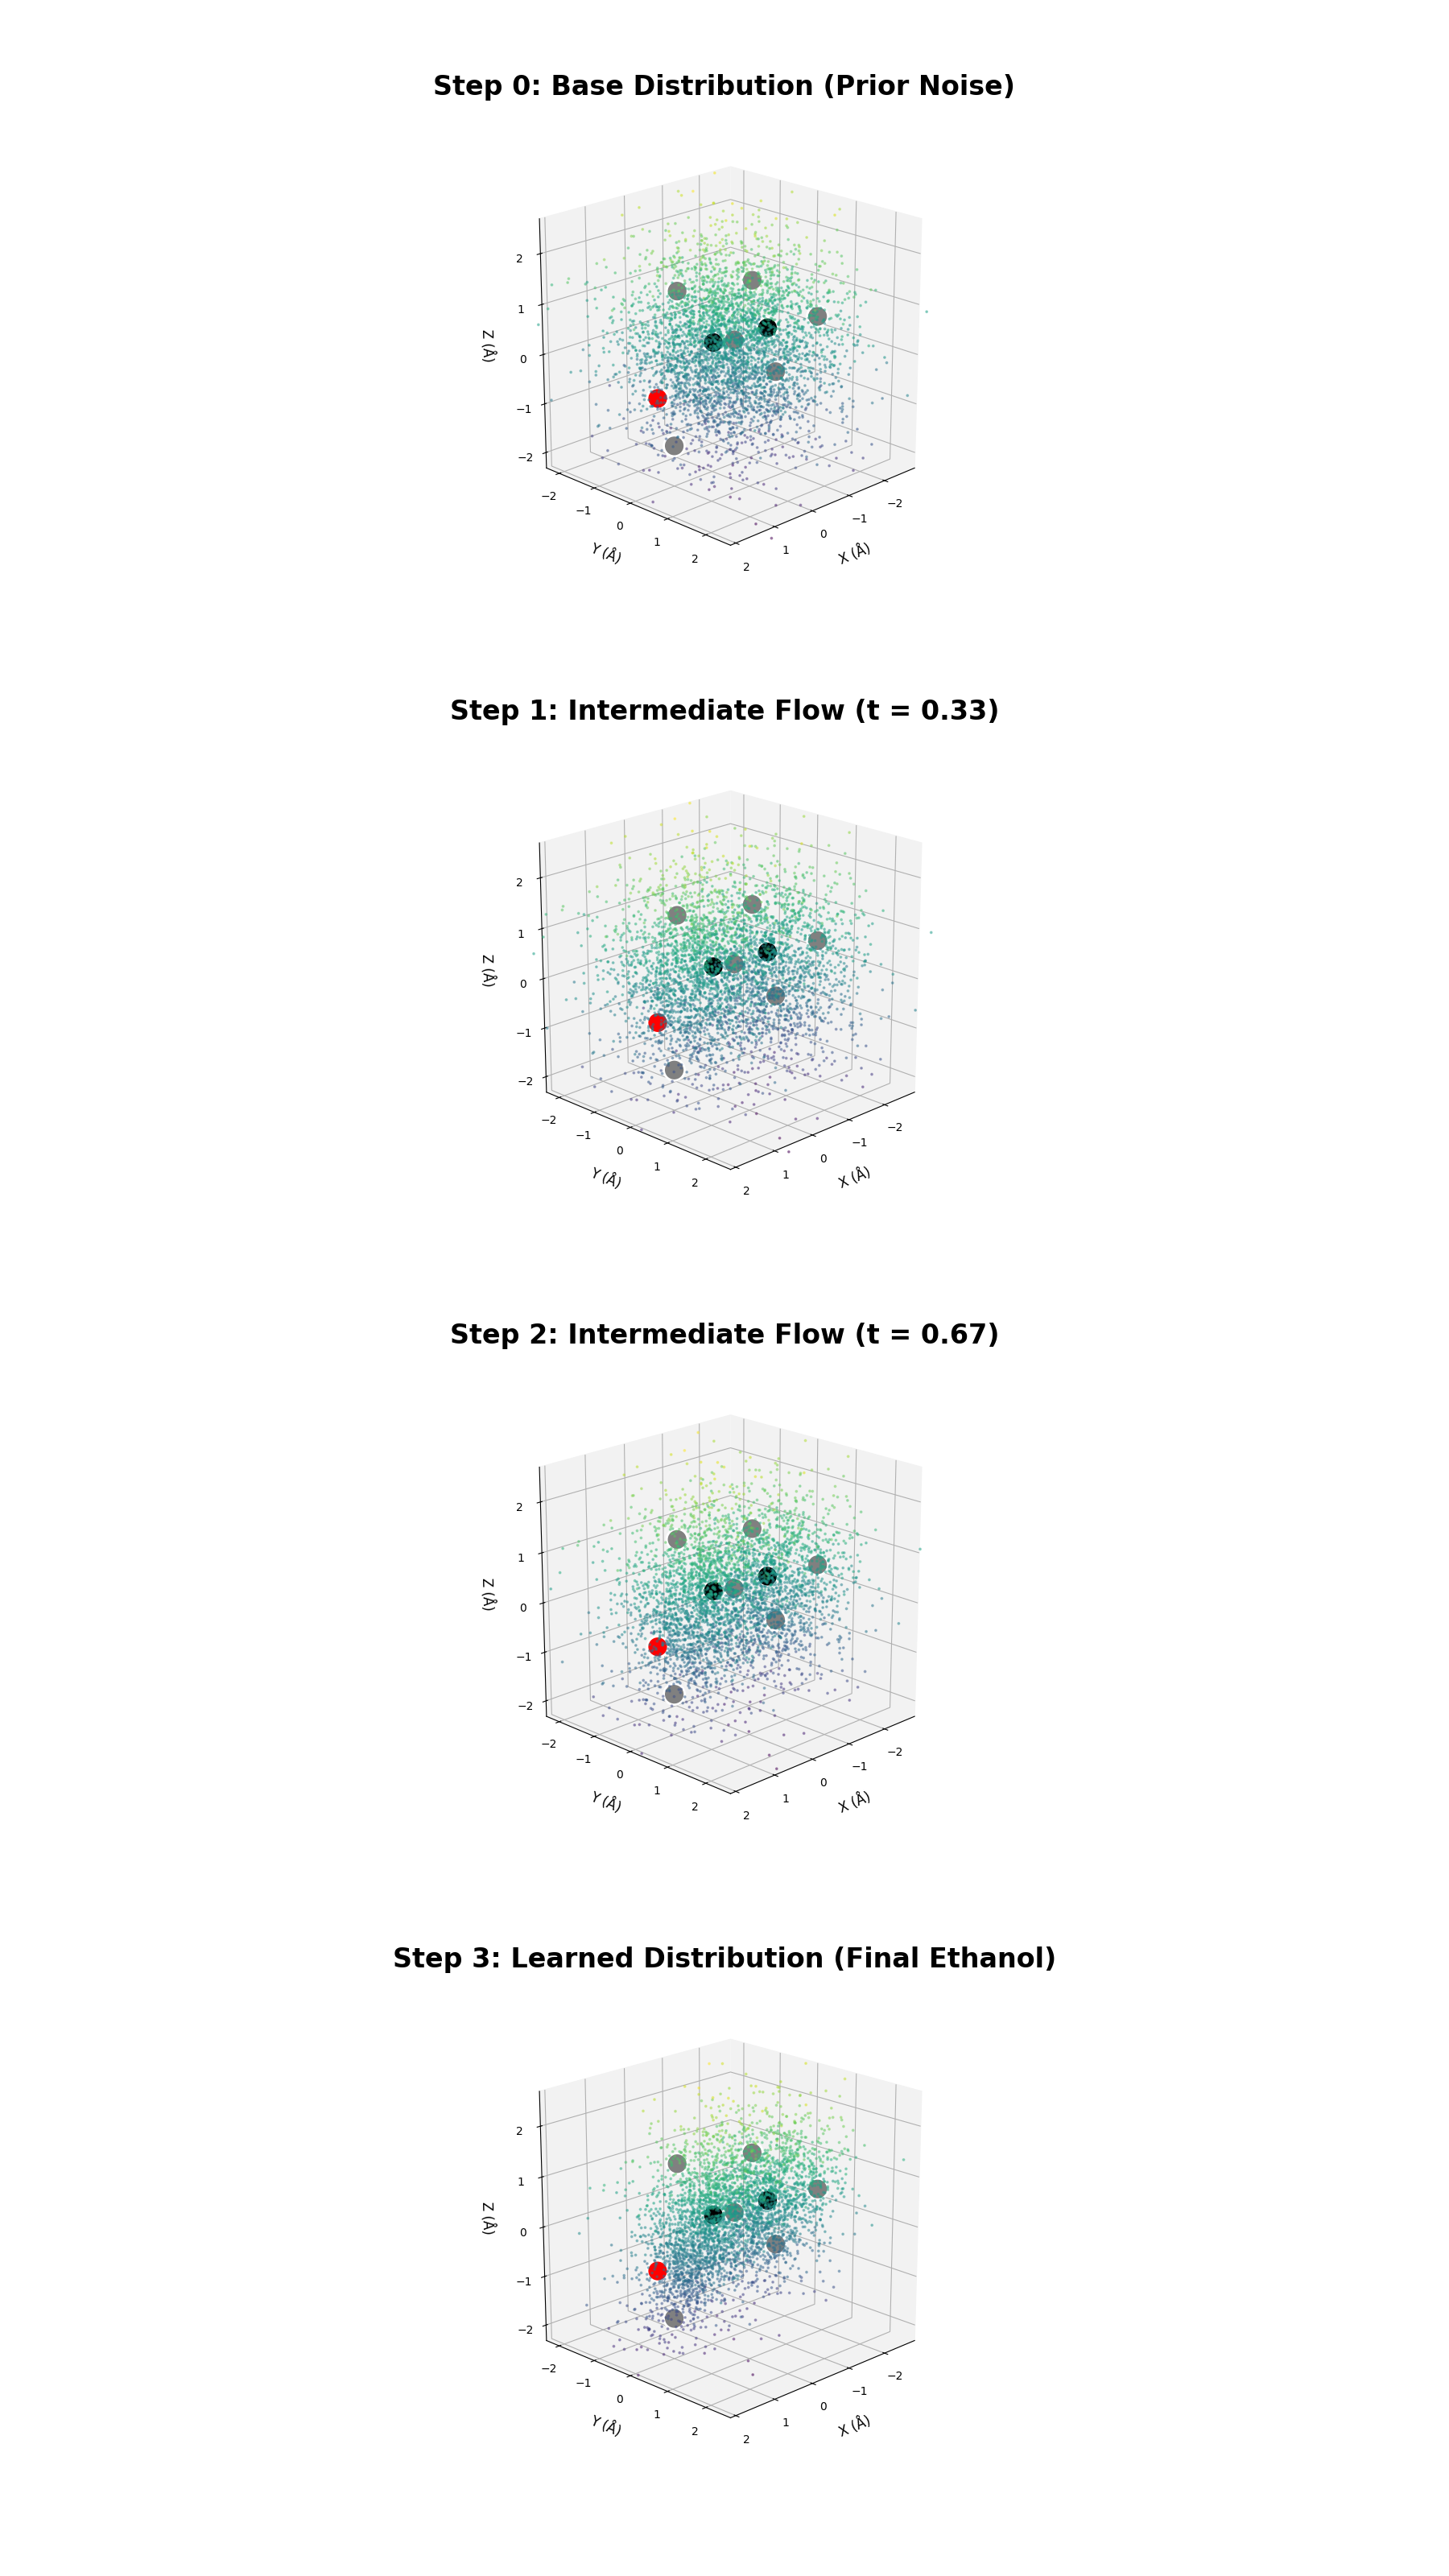

In [43]:
# 1. Determine number of snapshots from the data shape
num_snaps = sample_flows.shape[0]

# 2. Create the figure - increased height slightly to accommodate the 1:1:1 ratio
fig = plt.figure(figsize=(18, 8 * num_snaps))

for i in range(num_snaps):
    ax = fig.add_subplot(num_snaps, 1, i + 1, projection='3d')
    data = sample_flows[i]

    # --- PLOTTING ---
    # Cloud: 'plasma' provides better contrast than 'viridis' on light backgrounds
    ax.scatter(data[:, 0], data[:, 1], data[:, 2],
               c=data[:, 2], s=3, alpha=0.4)

    # Atoms: Increased size for clarity
    ax.scatter(target_atoms[:, 0], target_atoms[:, 1], target_atoms[:, 2],
               c=c_list, s=350, edgecolors='white', linewidth=2, alpha=1.0)

    # --- FORMATTING & RATIOS ---
    ax.set_box_aspect((1, 1, 1))  # Forces equal 1:1:1 axis ratios
    ax.view_init(elev=20, azim=45) # Standardized viewing angle
    
    # Axis Labels
    ax.set_xlabel('X (Å)', fontsize=12, labelpad=10)
    ax.set_ylabel('Y (Å)', fontsize=12, labelpad=10)
    ax.set_zlabel('Z (Å)', fontsize=12, labelpad=10)

    # Grid and Panes
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_axis_on()
    ax.xaxis.set_pane_color((0.95, 0.95, 0.95, 1.0))
    ax.yaxis.set_pane_color((0.95, 0.95, 0.95, 1.0))
    ax.zaxis.set_pane_color((0.95, 0.95, 0.95, 1.0))

    # --- TITLE LOGIC ---
    if i == 0:
        current_title = f"Step {i}: Base Distribution (Prior Noise)"
    elif i == num_snaps - 1:
        current_title = f"Step {i}: Learned Distribution (Final Ethanol)"
    else:
        # Calculate t as a progress percentage from 0 to 1
        t_val = i / (num_snaps - 1)
        current_title = f"Step {i}: Intermediate Flow (t = {t_val:.2f})"
    
    ax.set_title(current_title, fontsize=24, fontweight='bold', pad=30)

    # Limits
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_zlim(*zlim)

# 3. Final Layout Adjustments
# Increased hspace to 0.4 to prevent titles from overlapping the plot above
plt.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.05, hspace=0.4)

plt.show()